# Определение возраста покупателей

# Содержание

1. Введение
2. Подготовка окружения
3. Исследовательский анализ данных
4. Обучение модели
5. Анализ обученной модели
6. Вывод

## Введение

**Заголовок проекта**: Определение возраста по фотографии

**Описание проекта**: 

Разработка для сетевого супермаркета "Хлеб-Соль" модели, которая сможет по фотографии определить приблизительный возраст покупателя. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
- анализировать покупки и предлагать товары, интересные определённым возрастным группам;
- контролировать добросовестность кассиров при продаже алкогольной продукции.

**Цель исследования**

Построить нейронную сеть, способную по изображению лица предсказать возраст с минимальной ошибкой (метрика — MAE).

**Ход исследования**

- исследовательский анализ данных;
- обучение модели;
- анализ обученной модели;
- выводы о качестве модели и её пригодности для практического применения.

**Описание данных**

В нашем распоряжении имеется набор изображений лиц и файл labels.csv, содержащий:
- file_name — имя файла с изображением;
- real_age — реальный возраст человека.

## Подготовка окружения

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.optimizers import Adam

## Исследовательский анализ данных

### Анализ распределения возраста

In [2]:
labels = pd.read_csv('/datasets/faces/labels.csv')
labels.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [3]:
labels.info()
print('\nРазмер выборки:', labels.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB

Размер выборки: (7591, 2)


Датасет содержит две колонки (наименования файлов фотографий и реальный возраст). Всего в нём 7591 строка, пропусков нет.

In [4]:
labels.duplicated().sum()

0

Дубликатов нет.

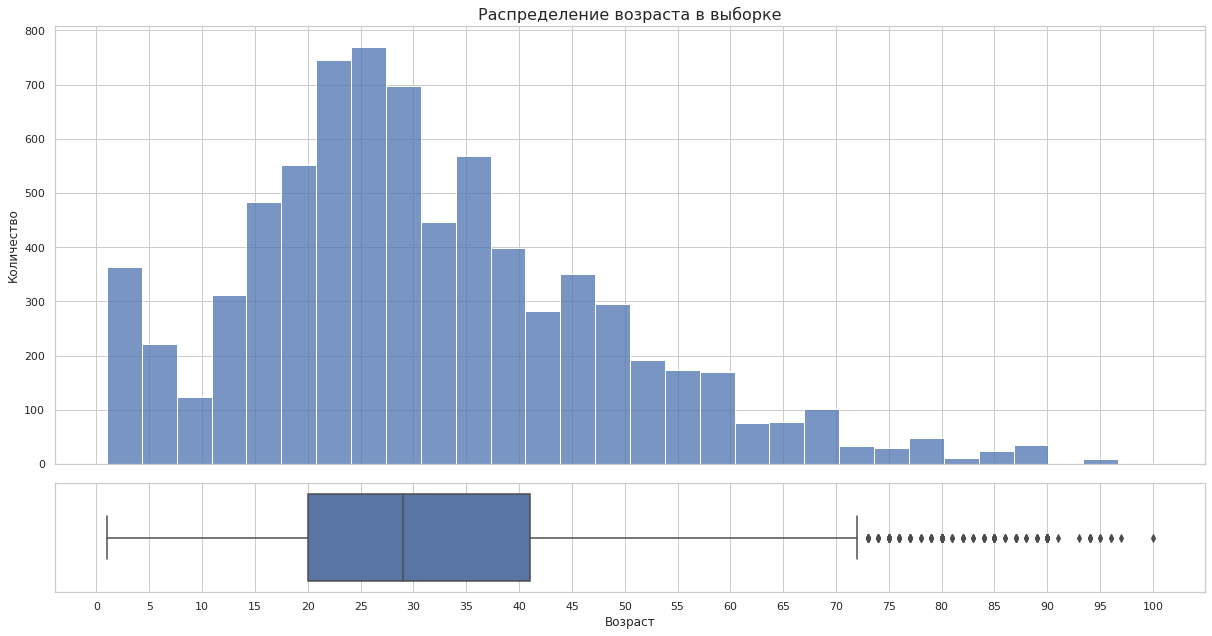

In [12]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(17, 9),
    gridspec_kw={'height_ratios': [4, 1]},
    sharex=True
)

# График распределения
sns.histplot(labels['real_age'], bins=30, ax=ax1)
ax1.set_title('Распределение возраста в выборке', fontsize=16)
ax1.set_xlabel('')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', labelbottom=False)

# Диаграмма размаха
sns.boxplot(x='real_age', data=labels, ax=ax2)
ax2.set_xlabel('Возраст')
ax2.set_ylabel('')
ax2.set_yticks([])

# Общие настройки оси X
ax2.set_xticks(range(0, 101, 5))

plt.tight_layout()
plt.show()

In [7]:
labels.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


Возраст людей варьируется от 1 до 100 лет, среднее значение составляет около 31 года, медианное — 29 лет.\
Распределение скошено вправо: наибольшее количество изображений приходится на возраст от 20 лет до 41 года; заметен пик в районе 25–30 лет; пожилые люди и дети представлены значительно меньше.

Такое распределение может повлиять на качество модели: сеть будет лучше распознавать возраст людей из наиболее представленных групп (20-40 лет) и хуже — для крайних возрастов. Это стоит учитывать при обучении и оценке результатов.

### Загрузка и анализ изображений

In [8]:
# Генератор изображений с нормализацией пикселей
train_datagen = ImageDataGenerator(rescale=1./255)
# Загрузка изображений и их меток из датафрейма
train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345)

Found 7591 validated image filenames.


Количество файлов в папке совпадает с количеством строк в датасете.

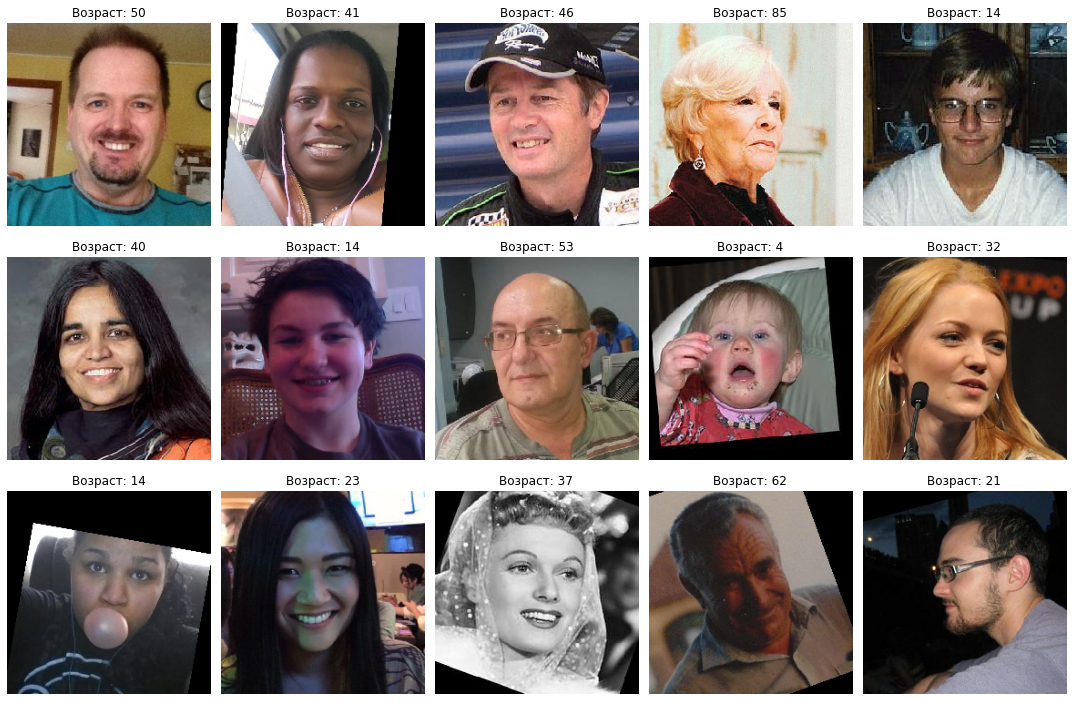

In [9]:
# Получаем один батч изображений и меток из генератора
features, labels_batch = next(train_gen_flow)

# Размер фигуры
plt.figure(figsize=(15, 10))

# Первые 15 изображений из батча
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(features[i])
    plt.title(f'Возраст: {int(labels_batch[i])}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Датасет содержит изображения людей разного возраста, качество фотографий неодинаково.\
Большинство изображений — фронтальные портреты, однако встречаются снимки с разными углами наклона головы и освещением.\
Эти особенности могут повлиять на точность модели, поэтому при обучении стоит использовать аугментацию изображений.

### Вывод по разделу

Датасет содержит две колонки (наименования файлов фотографий и реальный возраст). Всего в нём 7591 строка, пропусков и дубликатов нет.

Возраст людей в выборке варьируется от 1 года до 100 лет, среднее значение составляет около 31 года, медианное — 29 лет.\
Распределение скошено вправо: наибольшее количество изображений приходится на возраст от 20 лет до 41 года; заметен пик в районе 25–30 лет; пожилые люди и дети представлены значительно меньше.

Такое распределение может повлиять на качество модели: сеть будет лучше распознавать возраст людей из наиболее представленных групп (20-40 лет) и хуже — для крайних возрастов. Это стоит учитывать при обучении и оценке результатов.

Количество изображений в папке совпадает с количеством строк в датасете.

Датасет содержит изображения людей разного возраста, качество фотографий неодинаково.\
Большинство изображений — фронтальные портреты, однако встречаются снимки с разными углами наклона головы и освещением.\
Эти особенности могут повлиять на точность модели, поэтому при обучении стоит использовать аугментацию изображений.

## Обучение модели

Модель обучалась во внешней вычислительной среде с GPU. Ниже приведён использованный код и результаты обучения.

```python
def load_train(path):
    """
    Загружает обучающую выборку с аугментацией изображений.

    Args:
        path (str): Путь к директории датасета, содержащей файл labels.csv
            и папку с изображениями.

    Returns:
        DirectoryIterator: Генератор Keras с батчами обучающих данных.
    """
    labels = pd.read_csv(path + 'labels.csv')

    train_datagen = ImageDataGenerator(
        rescale=1/255.,
        validation_split=0.25,
        # аугментация
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15
    )
    
    # Генератор обучающих данных
    train_data = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(240, 240),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_data


def load_test(path):
    """
    Загружает валидационную выборку без аугментации.

    Args:
        path (str): Путь к директории датасета, содержащей файл labels.csv
            и папку с изображениями.

    Returns:
        DirectoryIterator: Генератор Keras с батчами валидационных данных.
    """
    labels = pd.read_csv(path + 'labels.csv')

    test_datagen = ImageDataGenerator(
        rescale=1/255.,
        validation_split=0.25
    )

    # Генератор валидационных данных
    test_data = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(240, 240),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return test_data


def create_model(input_shape):
    """
    Создаёт и компилирует модель предсказания возраста на основе ResNet50.

    Модель использует предобученную сверточную сеть для извлечения
    признаков и полносвязные слои для задачи регрессии.

    Args:
        input_shape (tuple): Размер входных изображений
            (высота, ширина, количество каналов).

    Returns:
        keras.Model: Скомпилированная модель Keras.
    """
    
    # Предобученная сверточная часть без полносвязных слоёв
    backbone = ResNet50(input_shape=input_shape,
                        weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5', 
                        include_top=False)
    
    # Полная архитектура модели
    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),       # Усреднение карт признаков
        BatchNormalization(),           # Нормализация для стабильного обучения
        Dense(256, activation='relu'),  # Полносвязный слой с 256 нейронами
        Dropout(0.3),                   # Регуляризация для предотвращения переобучения
        Dense(1, activation='relu')     # Выходной слой с одним значением
    ])

    # Компиляция модели
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='mse',
        metrics=['mae'])
    
    return model

def train_model(
        model,
        train_data,
        test_data,
        batch_size=32,
        epochs=5,
        steps_per_epoch=None,
        validation_steps=None):

    """
    Обучает модель в два этапа: замороженный backbone и fine-tuning.

    Этап 1:
        Обучаются только верхние слои, сверточная часть заморожена.

    Этап 2:
        Сверточная часть размораживается и дообучается с меньшим
        шагом обучения.

    Args:
        model (keras.Model): Скомпилированная модель.
        train_data (DirectoryIterator): Генератор обучающих данных.
        test_data (DirectoryIterator): Генератор валидационных данных.
        batch_size (int, optional): Размер батча. По умолчанию 32.
        epochs (int, optional): Количество эпох первого этапа обучения.
            По умолчанию 5.
        steps_per_epoch (int, optional): Шаги обучения на эпоху.
        validation_steps (int, optional): Шаги валидации.

    Returns:
        keras.Model: Обученная модель.
    """
    print('Этап 1: обучение верхних слоёв (ResNet50 заморожен)')
    # Замораживаем сверточную часть
    model.layers[0].trainable = False
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='mse',
        metrics=['mae']
    )

    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        verbose=2
    )

    print('\nЭтап 2: fine-tuning — размораживаем ResNet50')
    # Размораживаем сверточную часть
    model.layers[0].trainable = True
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='mse',
        metrics=['mae']
    )

    model.fit(
        train_data,
        validation_data=test_data,
        epochs=15,
        verbose=2
    )

    return model
```

```

Found 5694 validated image filenames.
Found 1897 validated image filenames.

Этап 1: обучение верхних слоёв (ResNet50 заморожен)

Train for 178 steps, validate for 60 steps
Epoch 1/5
178/178 - 135s - loss: 925.5865 - mae: 25.6033 - val_loss: 582.8433 - val_mae: 19.1259
Epoch 2/5
178/178 - 111s - loss: 401.6495 - mae: 15.5288 - val_loss: 283.8346 - val_mae: 12.8454
Epoch 3/5
178/178 - 111s - loss: 235.7029 - mae: 11.8877 - val_loss: 286.9693 - val_mae: 13.4425
Epoch 4/5
178/178 - 111s - loss: 199.9084 - mae: 10.9870 - val_loss: 287.6062 - val_mae: 13.4743
Epoch 5/5
178/178 - 112s - loss: 182.8324 - mae: 10.5066 - val_loss: 286.5227 - val_mae: 13.4116

Этап 2: fine-tuning — размораживаем ResNet50

Train for 178 steps, validate for 60 steps
Epoch 1/15
178/178 - 127s - loss: 158.5095 - mae: 9.7129 - val_loss: 385.8913 - val_mae: 14.6544
Epoch 2/15
178/178 - 121s - loss: 120.6444 - mae: 8.4744 - val_loss: 284.8062 - val_mae: 13.0475
Epoch 3/15
178/178 - 122s - loss: 101.0239 - mae: 7.8118 - val_loss: 266.6907 - val_mae: 12.4868
Epoch 4/15
178/178 - 122s - loss: 87.9176 - mae: 7.2733 - val_loss: 209.7683 - val_mae: 11.3272
Epoch 5/15
178/178 - 121s - loss: 76.7644 - mae: 6.7836 - val_loss: 124.5609 - val_mae: 8.6196
Epoch 6/15
178/178 - 122s - loss: 67.8342 - mae: 6.4323 - val_loss: 106.0826 - val_mae: 7.9735
Epoch 7/15
178/178 - 122s - loss: 61.2585 - mae: 6.0843 - val_loss: 105.5509 - val_mae: 7.8378
Epoch 8/15
178/178 - 121s - loss: 54.6276 - mae: 5.7699 - val_loss: 101.9017 - val_mae: 7.7378
Epoch 9/15
178/178 - 122s - loss: 51.0014 - mae: 5.6134 - val_loss: 102.1864 - val_mae: 7.6487
Epoch 10/15
178/178 - 121s - loss: 47.1107 - mae: 5.3608 - val_loss: 105.0306 - val_mae: 7.8021
Epoch 11/15
178/178 - 123s - loss: 44.3865 - mae: 5.2008 - val_loss: 105.1262 - val_mae: 7.7684
Epoch 12/15
178/178 - 122s - loss: 42.7803 - mae: 5.1006 - val_loss: 102.5498 - val_mae: 7.7291
Epoch 13/15
178/178 - 120s - loss: 39.6007 - mae: 4.8900 - val_loss: 99.5367 - val_mae: 7.4670
Epoch 14/15
178/178 - 115s - loss: 36.5577 - mae: 4.6853 - val_loss: 101.9683 - val_mae: 7.6969
Epoch 15/15
178/178 - 114s - loss: 35.5432 - mae: 4.6919 - val_loss: 100.9733 - val_mae: 7.6012

60/60 - 10s - loss: 100.9733 - mae: 7.6012

```

### Вывод по разделу

На данном этапе мы подготовили функции:
- для загрузки тренировочной выборки (использовался ImageDataGenerator, проведены нормализация и аугментация);
- для загрузки тестовой выборки (размер тестовой выборки — 25%, использовался ImageDataGenerator, проведена нормализация);
- для построения модели (сверточный слой — предобученная модель ResNet50 без топа, затем глобальный двумерный пулинг усреднением, нормализация для ускорения и стабилизации обучения, полносвязный слой с 256 нейронами, регуляризация для предотвращения переобучения и выходной слой с одним значением);
- для обучения модели (в два этапа: Этап 1 — обучение верхних слоёв (ResNet50 заморожен), Этап 2 — fine-tuning (разморозка ResNet50)).

## Анализ обученной модели

На первом этапе обучения (ResNet50 заморожен) ошибка MAE снизилась с 25.6 до 10.5 на обучающей выборке и с 19.1 до 13.4 на тесте.\
Модель быстро освоила базовые закономерности между изображением и возрастом.

На втором этапе обучения (задействованы все слои ResNet50) ошибка MAE постепенно уменьшалась с 9.7 до 4.7 на тренировочной выборке и с 11.1 до 7.6 на тесте.\
Разница между тренировочной и валидационной ошибками небольшая, что указывает на отсутствие сильного переобучения.\
Процесс обучения стабилен, улучшения наблюдались примерно до 13-й эпохи.

Итоговое значение MAE на тестовой выборке — 7.60, то есть средняя ошибка предсказания возраста составляет около 7,6 лет, что соответствует условию задачи (MAE ≤ 8).

## Вывод

Датасет содержит две колонки (наименования файлов фотографий и реальный возраст). Всего в нём 7591 строка, пропусков и дубликатов нет.

Возраст людей в выборке варьируется от 1 года до 100 лет, среднее значение составляет около 31 года, медианное — 29 лет.\
Распределение скошено вправо: наибольшее количество изображений приходится на возраст от 20 лет до 41 года; заметен пик в районе 25–30 лет; пожилые люди и дети представлены значительно меньше.

Такое распределение может повлиять на качество модели: сеть будет лучше распознавать возраст людей из наиболее представленных групп (20-40 лет) и хуже — для крайних возрастов. Это стоит учитывать при обучении и оценке результатов.

Количество изображений в папке совпадает с количеством строк в датасете.

Датасет содержит изображения людей разного возраста, качество фотографий неодинаково.\
Большинство изображений — фронтальные портреты, однако встречаются снимки с разными углами наклона головы и освещением.\
Эти особенности могут повлиять на точность модели, поэтому при обучении стоит использовать аугментацию изображений.Модель на основе предобученной архитектуры ResNet50 успешно прошла обучение и показала требуемое качество.

Были подготовлены функции:

- для загрузки тренировочной выборки (использовался ImageDataGenerator, проведены нормализация и аугментация);
- для загрузки тестовой выборки (размер тестовой выборки — 25%, использовался ImageDataGenerator, проведена нормализация);
- для построения модели (сверточный слой — предобученная модель ResNet50 без топа, затем глобальный двумерный пулинг усреднением, нормализация для ускорения и стабилизации обучения, полносвязный слой с 256 нейронами, регуляризация для предотвращения переобучения и выходной слой с одним значением);
- для обучения модели (в два этапа: Этап 1 — обучение верхних слоёв (ResNet50 заморожен), Этап 2 — fine-tuning (разморозка ResNet50)).

На первом этапе обучения (ResNet50 заморожен) ошибка MAE снизилась с 25.6 до 10.5 на обучающей выборке и с 19.1 до 13.4 на тесте.\
Модель быстро освоила базовые закономерности между изображением и возрастом.

На втором этапе обучения (задействованы все слои ResNet50) ошибка MAE постепенно уменьшалась с 9.7 до 4.7 на тренировочной выборке и с 11.1 до 7.6 на тесте.\
Разница между тренировочной и валидационной ошибками небольшая, что указывает на отсутствие сильного переобучения.\
Процесс обучения стабилен, улучшения наблюдались примерно до 13-й эпохи.

Итоговое значение MAE на тестовой выборке — 7.60, то есть средняя ошибка предсказания возраста составляет около 7,6 лет, что соответствует условию задачи (MAE ≤ 8).

Достигнутая точность позволит заказчику анализировать покупки и предлагать товары, интересные определённым возрастным группам.

Для более надежного определения совершеннолетия покупателей при продаже алкогольной продукции можно разработать решение, предусматривающее сканирование паспорта и сопоставление фотографии в паспорте с лицом покупателя. 